### 1. 머신러닝

#### 문제1. 신생아 건강 데이터 분석 (Newborn_Health.csv)
##### 데이터셋은 신생아(체중 1800g 이하, Low Birth Weight) 관련 정보를 포함하며, 연속형 변수 6~7개와 범주형(Yes/No) 변수 8~10개로 구성됩니다.

- 변수 예시:
- 연속형: 출생체중(g), 임신기간(주), 모체연령, 병원입원일수 등
- 범주형: 쌍둥이여부(Yes/No), 제왕절개여부(Yes/No), 신생아호흡곤란증후군(RDS, Yes/No), 생존여부(0: 사망, 1: 생존) 등
- 뇌손상 관련 변수: D, E, F (각각 None, Mild, Severe, NA)
- 종속변수: 생존여부 (survival, 0/1)


각 컬럼에 대한 설명:

Maternal Age (엄마 나이): 출산 당시 엄마의 나이를 의미합니다.

Gestational Age (임신 주수): 임신 기간을 주 단위로 나타냅니다. 예를 들어, 40주는 만삭을 의미합니다. (마지막 월경 첫날부터 현재까지의 기간을 주단위로 계산하여 태아의 성장과 발달단계를 파악하는 중요한 의학적 지표이다.)

Birth Weight (출생 시 체중): 신생아의 출생 당시 체중을 그램(g) 또는 킬로그램(kg) 단위로 나타냅니다.

APGAR Score 1min (아프가 점수 1분): 출생 후 1분에 측정한 아프가 점수입니다. 아프가 점수는 신생아의 건강 상태를 평가하는 지표로, 피부색, 심박수, 반사 반응, 근긴장도, 호흡 등 5가지 항목을 평가하여 총 0점에서 10점까지 매깁니다.

APGAR Score 5min (아프가 점수 5분): 출생 후 5분에 측정한 아프가 점수입니다. 일반적으로 1분 점수보다 5분 점수가 신생아의 장기적인 예후와 더 관련이 깊다고 알려져 있습니다.

Sex (성별): 신생아의 성별을 나타냅니다 (예: 남, 여 또는 M, F).

Presence of Congenital Abnormality (선천성 기형 유무): 신생아에게 선천성 기형이 있는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

Mode of Delivery (분만 방식): 분만 방식을 나타냅니다 (예: 자연 분만, 제왕절개 등).

NICU Admission (신생아 중환자실 입원 여부): 신생아가 출생 후 신생아 중환자실(NICU)에 입원했는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

Respiratory Distress Syndrome (RDS) (호흡곤란 증후군 (RDS) 발생 여부): 신생아에게 호흡곤란 증후군이 발생했는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

#### 데이터 특이사항:

- 결측값 비율: 약 10~15%
- BrainDamage 변수의 NA 비율: 약 20%
- Python/R로 분석 가능, sklearn/xgboost 패키지 사용 권장.

In [78]:
d1 = pd.read_csv('Newborn_Health.csv')

In [79]:
d1.isna().sum()

id                   0
birth_weight         0
gestational_age      0
maternal_age         0
hospital_days        0
apgar_score          0
oxygen_days          0
body_temp            0
twins                0
c_section            0
rds                  0
d                  203
e                  206
f                  200
infection            0
ventilation          0
gender               0
survival             0
dtype: int64

#### 1. 교차표 생성:
- 뇌손상 변수 D, E, F를 두 개씩 조합하여 교차표를 작성하고, 각 조합의 데이터 분포를 추정하시오. (예: D와 E의 교차표, E와 F의 교차표 등)

In [80]:
d1['d'].unique()

array(['Severe', 'None', nan, 'Mild'], dtype=object)

In [85]:
cc = [('d', 'e'), ('d', 'f'), ('e', 'f')]
idx = ['None', 'Mild', 'Severe', 'All']

for a, b in cc:
    cr = pd.crosstab(d1[a], d1[b], margins=True, )
    cr = cr.reindex(index=idx, columns=idx)
    display(cr)

e,None,Mild,Severe,All
d,,,,
None,242,94,48,384
Mild,102,33,21,156
Severe,49,25,10,84
All,393,152,79,624


f,None,Mild,Severe,All
d,,,,
None,216,123,49,388
Mild,89,43,24,156
Severe,52,31,8,91
All,357,197,81,635


f,None,Mild,Severe,All
e,,,,
None,234,114,55,403
Mild,89,48,16,153
Severe,43,25,13,81
All,366,187,84,637


In [94]:
for a, b in cc:
    cr = pd.crosstab(d1[a], d1[b], margins=True, normalize=True)
    cr = cr.reindex(index=idx, columns=idx)
    display(cr)

e,None,Mild,Severe,All
d,,,,
None,0.387821,0.150641,0.076923,0.615385
Mild,0.163462,0.052885,0.033654,0.250000
Severe,0.078526,0.040064,0.016026,0.134615
All,0.629808,0.243590,0.126603,1.000000


f,None,Mild,Severe,All
d,,,,
None,0.340157,0.193701,0.077165,0.611024
Mild,0.140157,0.067717,0.037795,0.245669
Severe,0.081890,0.048819,0.012598,0.143307
All,0.562205,0.310236,0.127559,1.000000


f,None,Mild,Severe,All
e,,,,
None,0.367347,0.178964,0.086342,0.632653
Mild,0.139717,0.075353,0.025118,0.240188
Severe,0.067504,0.039246,0.020408,0.127159
All,0.574568,0.293564,0.131868,1.000000


다음과 같은 빈도표를 생성하여 뇌손상 변수 간 분포를 확인할 수 있다.  
전반적으로 보면 None>>Mild>Severe 순으로 빈도가 불균형 한 것을 알 수 있다.  

e-d 빈도표를 보면, 모두 None 인 비율이 가장 높으며, 둘 다 중증인 비율이 가장 낮다.  
다른 도표도 마찬가지이다. 

#### 2. 파생변수 생성:
- BrainDamage: D, E, F가 모두 NA이면 0, 하나라도 None/Mild/Severe이면 1, 그 외는 NA로 처리.
- SplitInd: BrainDamage가 0이면 0, NA이면 1, 그 외(1)는 2로 처리.

In [96]:
cond1 = d1[['d', 'e', 'f']].isna().all(axis=1)
cond2 = d1[['d', 'e', 'f']].isin(['None', 'Mild', 'Severe']).any(axis=1)

d1['brain'] = np.where(cond1, 0, 
                      np.where(cond2, 1, np.nan))
d1['sp'] = np.where(d1['brain'] == 0, 0, 
                   np.where(d1['brain'].isna(), 1, 2))

print(d1[['brain', 'sp']].value_counts())

brain  sp
1.0    2     994
0.0    0       6
dtype: int64


#### 3. 데이터 전처리:
- 결측값 처리: 연속형 변수는 중앙값으로, 범주형 변수는 최빈값으로 대체.
- 불필요한 변수(예: ID, 상수값 변수) 제거.

In [98]:
d1.isna().sum()[d1.isna().sum()>0]

d    203
e    206
f    200
dtype: int64

In [100]:
# 모두 범주형 변수이므로 최빈값으로 대치한다. 

for c in ['d', 'e', 'f']:
    d1[c] = d1[c].fillna(d1[c].mode()[0])
d1.isna().sum()[d1.isna().sum()>0]

Series([], dtype: int64)

#### 4. EDA (탐색적 데이터 분석):
- 생존여부(survival)와 BrainDamage에 따른 주요 변수(출생체중, 임신기간 등)의 분포를 시각화하고 상관관계 분석.

In [102]:
#불필요 변수: id 식제(식별자 역할만을 수행)
d1.drop(columns='id', inplace=True)

In [104]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   birth_weight     1000 non-null   float64
 1   gestational_age  1000 non-null   float64
 2   maternal_age     1000 non-null   float64
 3   hospital_days    1000 non-null   int64  
 4   apgar_score      1000 non-null   int64  
 5   oxygen_days      1000 non-null   int64  
 6   body_temp        1000 non-null   float64
 7   twins            1000 non-null   object 
 8   c_section        1000 non-null   object 
 9   rds              1000 non-null   object 
 10  d                1000 non-null   object 
 11  e                1000 non-null   object 
 12  f                1000 non-null   object 
 13  infection        1000 non-null   object 
 14  ventilation      1000 non-null   object 
 15  gender           1000 non-null   object 
 16  survival         1000 non-null   int64  
 17  brain          

In [110]:
d1[['survival', 'sp', 'brain']] = d1[['survival', 'sp', 'brain']].astype('O')

<<연속형 변수 통계량>>


,count,mean,std,min,25%,50%,75%,max
birth_weight,1000.0,1497.507539,183.028100,851.746532,1370.481939,1505.060122,1629.588775,1800.000000
gestational_age,1000.0,32.141142,1.907676,28.000000,30.787517,32.126154,33.457764,36.000000
maternal_age,1000.0,30.035634,4.867969,18.000000,26.760002,29.998746,33.304577,45.000000
hospital_days,1000.0,9.975000,3.067864,5.000000,8.000000,10.000000,12.000000,21.000000
apgar_score,1000.0,6.416000,1.735499,4.000000,5.000000,6.000000,8.000000,9.000000
oxygen_days,1000.0,1.929000,1.337815,0.000000,1.000000,2.000000,3.000000,7.000000
body_temp,1000.0,36.806771,0.305139,36.000000,36.605420,36.808658,37.006225,37.813215


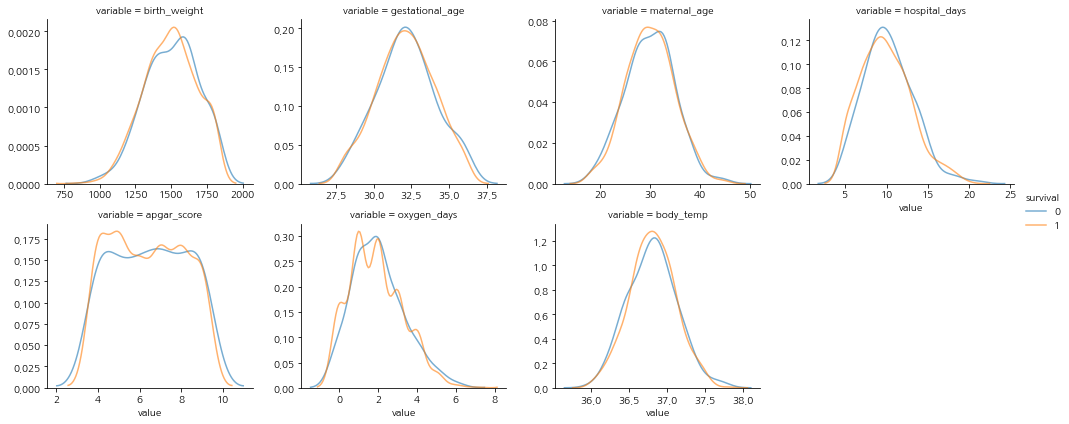

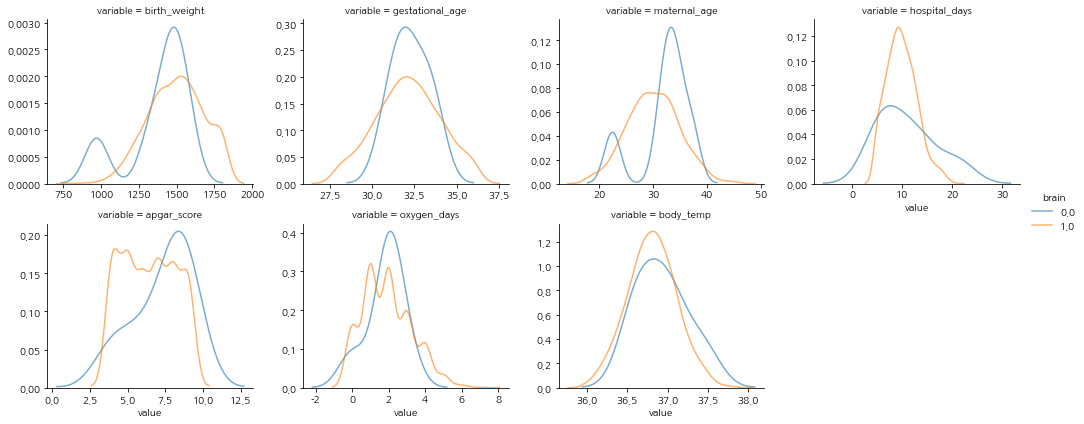

In [111]:
ob = ['survival', 'brain']
n_cols = d1.select_dtypes('number').columns
c_cols = d1.select_dtypes('O').columns

print(f"<<연속형 변수 통계량>>")
display(d1[n_cols].describe().T)

for o in ob:
    mt = d1.melt(id_vars=o, value_vars=n_cols)
    g = sns.FacetGrid(mt, col='variable', hue=o, col_wrap=4, aspect=1.2, sharex=False, sharey=False)
    g.map(sns.kdeplot, 'value', alpha=0.6)
    g.add_legend()
    plt.show()
    


각 목적변수 범주에 따라 설명변수의 분포를 확인할 수 있다.  
생존여부에 따른 연속형 변수의 분포는 큰 차이가 존재하지 않는 것을 알 수 있다.  
=> 종속변수를 예측하는 특징이 명확하지 않음  

뇌손상 여부에 대한 분포의 차이는 명확하다.  
예를 들어 뇌손상이 없는 경우 신생아 몸무게는 이봉분포를 보이나, 뇌손상이 있는 경우는 비교적 높으며,  
아프가 점수는 뇌손상이 없는 경우 왼쪽으로 약간 치우친 정규분포 형태를 보이나, 뇌손상이 있는 경우 균등한 분포를 보이고 있다.  
=> 해당 종속변수로 예측한다면 예측특징이 명확함, 단 데이터가 정상에 매우 불균형한 분포를 보이고 있어 추가적인 데이터 수집이 필요


<<범주형 변수 통계량>>


,count,unique,top,freq
twins,1000,2,No,904
c_section,1000,2,No,587
rds,1000,2,No,675
d,1000,3,None,699
e,1000,3,None,707
f,1000,3,None,654
infection,1000,2,No,803
ventilation,1000,2,No,720
gender,1000,2,F,501
survival,1000,2,1,813


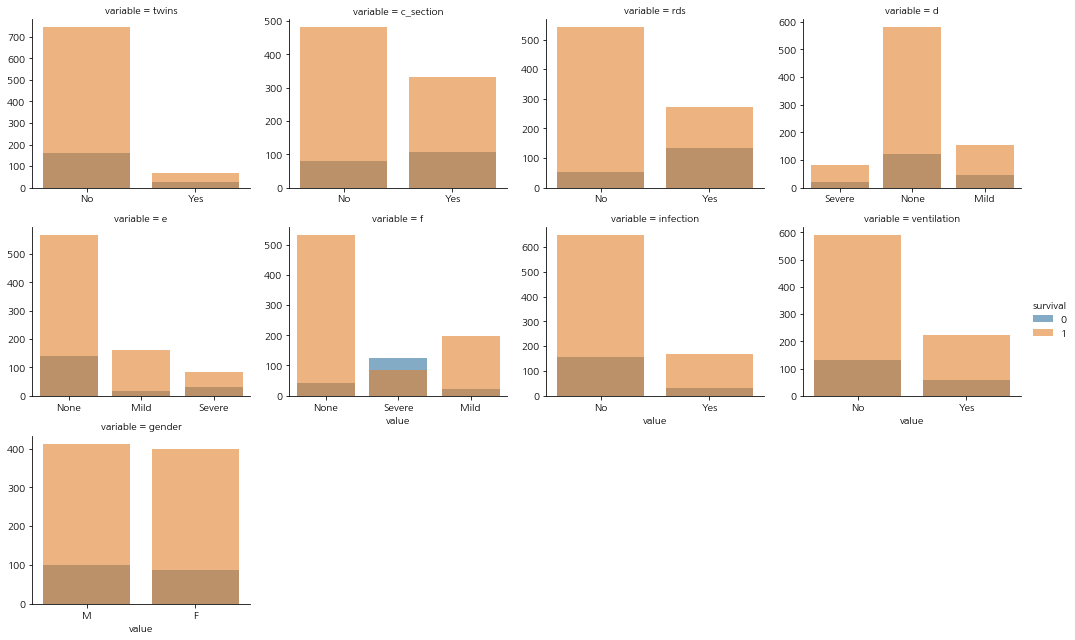

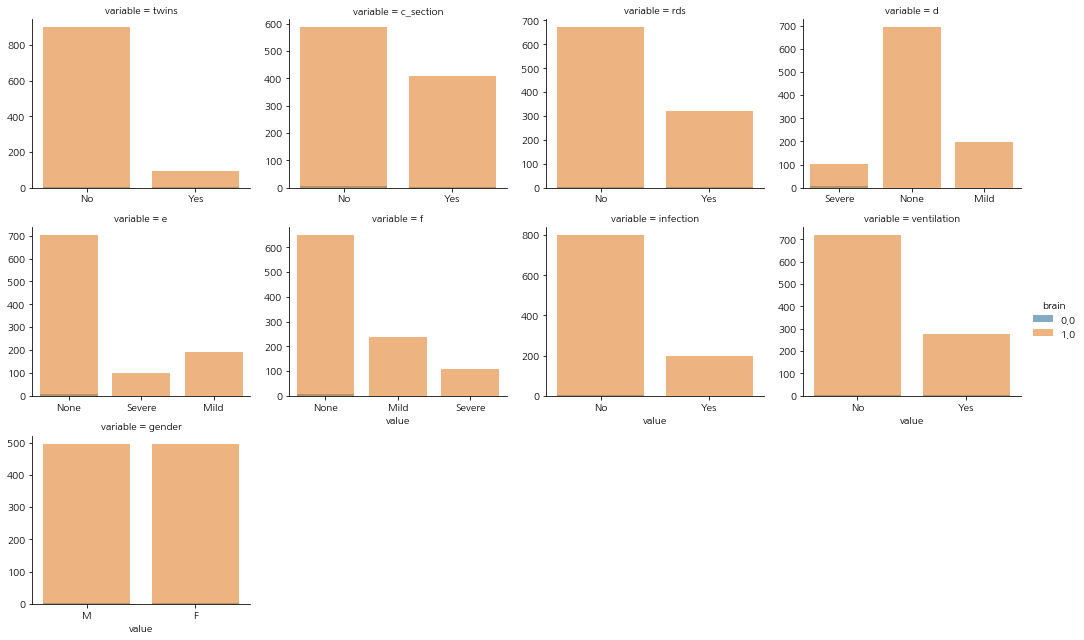

In [114]:
print(f"<<범주형 변수 통계량>>")
display(d1[c_cols].describe().T)

for o in ob:
    mt = d1.melt(id_vars=o, value_vars=c_cols[:-3])
    g = sns.FacetGrid(mt, col='variable', hue=o, col_wrap=4, aspect=1.2, sharex=False, sharey=False)
    g.map(sns.countplot, 'value', alpha=0.6)
    g.add_legend()
    plt.show()

목적변수 범주별 분포 및 범주형 변수 통계량이다.  

생존여부에 따른 빈도 분포는 다음과 같은 차이가 있다. 
- c_section, rbs: 사망영아의 경우 Yes 가 많으며, 생존의 경우 no가 많음 => 사망영아의 경우 의료조치 했음  
- e, f: 중증 비율이 정상보다 다소 높음(특히 f)

뇌손상 분포의 차이는 불균형 데이터로 비교가 어려움

- 생존여부별 birth_weight, gestational_age 박스플롯.
- BrainDamage와 survival 간 상관관계(크래머 V 등).

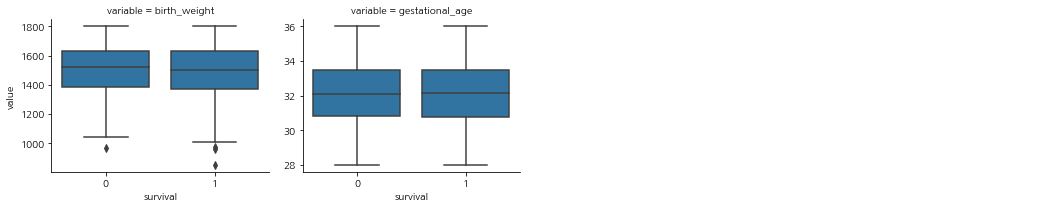

In [122]:
cc = ['birth_weight', 'gestational_age']

mt = d1.melt(id_vars='survival', value_vars=cc)
g = sns.FacetGrid(mt, col='variable', col_wrap=4, aspect=1.2, sharex=False, sharey=False)
g.map(sns.boxplot,'survival', 'value')
g.add_legend()
plt.show()

생존여부 별 출생 몸무게가 사망의 경우 다소 높으며, 임신주수는 큰 차이를 보이지 않음을 알 수 있다. 

뇌손상과 생존 상관관계 분석 

두 변수는 모두 명목형 변수이므로 카이제곱 독립성 검정을 수행한다.    
이후 효과측정을 위해 크레이머 v 계수를 확인한다.  

- 귀무가설: 두 변수는 서로 독립적이다.
- 대립가설: 두 변수는 서로 연관이 있다.

In [124]:
from scipy.stats import chi2_contingency


cr = pd.crosstab(d1['survival'], d1['brain'])

s, p, ddof, expected = chi2_contingency(cr)

v = association(cr, method='cramer')

print(f"카이제곱 독립성 검정 통계량/pvalue: {s} / {p:.3f}")
print(f"크레이머 v 계수: {v:.3f}")

카이제곱 독립성 검정 통계량/pvalue: 0.15758461418311548 / 0.691
크레이머 v 계수: 0.029


카이제곱 독립성 검정결과 귀무가설을 기각할 수 없으므로(0.691) 두 변수는 서로 영향을 미치지 않는다.  
통계적으로 유의하지 않으므로 크레이머 v 계수는 해석할 필요가 없다. 

#### 분류 분석:
- 단일 분류: 로지스틱 회귀 또는 의사결정나무를 사용하여 survival 예측.
- 앙상블 분류: 랜덤포레스트와 XGBoost를 사용하여 survival 예측.
- 모델 성능 비교(Accuracy, F1-Score, ROC-AUC).

불균형 데이터이므로 오버샘플링 고려

In [143]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 750 entries, 237 to 695
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   birth_weight     750 non-null    float64
 1   gestational_age  750 non-null    float64
 2   maternal_age     750 non-null    float64
 3   hospital_days    750 non-null    int64  
 4   apgar_score      750 non-null    int64  
 5   oxygen_days      750 non-null    int64  
 6   body_temp        750 non-null    float64
 7   twins            750 non-null    object 
 8   c_section        750 non-null    object 
 9   rds              750 non-null    object 
 10  d                750 non-null    object 
 11  e                750 non-null    object 
 12  f                750 non-null    object 
 13  infection        750 non-null    object 
 14  ventilation      750 non-null    object 
 15  gender           750 non-null    object 
 16  sp               750 non-null    object 
dtypes: float64(4),

In [146]:
x = d1.drop(columns=['survival', 'brain', 'sp'])
y = d1['survival'].astype('int64')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, classification_report

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42, stratify=y)

c_cols = train_x.select_dtypes('O').columns
n_cols = train_x.select_dtypes('number').columns

pre = make_column_transformer(
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

lr = Pipeline([
    ('pre', pre), 
    ('cl', LogisticRegression(solver='liblinear'))
])

rf = Pipeline([
    ('pre', pre), 
    ('cl', RandomForestClassifier(random_state=42))
])

m_list = [('로지스틱회귀',  lr), ('랜덤포레스트분류', rf)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'acc', 'f1', 'roc_auc', 'pr_auc'])

for n1, model in m_list:
    model.fit(train_x, train_y)
    for n2, x, y, in d_list:
        pred = model.predict(x)
        acc = accuracy_score(y, pred)
        f1 = f1_score(y, pred, average='macro')
        roc = roc_auc_score(y, pred, average='macro')
        pr = average_precision_score(y, pred, average='macro')
        rs.loc[len(rs)] = [n1, n2, acc, f1, roc, pr]
        print(classification_report(y, pred))
display(rs)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       140
           1       0.81      1.00      0.90       610

    accuracy                           0.81       750
   macro avg       0.41      0.50      0.45       750
weighted avg       0.66      0.81      0.73       750

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        47
           1       0.81      1.00      0.90       203

    accuracy                           0.81       250
   macro avg       0.41      0.50      0.45       250
weighted avg       0.66      0.81      0.73       250

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       140
           1       1.00      1.00      1.00       610

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750

              preci

,model,data,acc,f1,roc_auc,pr_auc
0,로지스틱회귀,train,0.813333,0.448529,0.5,0.813333
1,로지스틱회귀,test,0.812000,0.448124,0.5,0.812000
2,랜덤포레스트분류,train,1.000000,1.000000,1.0,1.000000
3,랜덤포레스트분류,test,0.812000,0.448124,0.5,0.812000


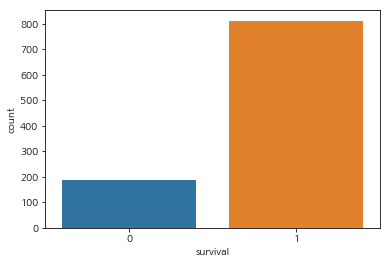

In [131]:
sns.countplot(d1['survival'])
plt.show()

단일모델인 로지스틱 회귀와 앙상블 모델인 랜덤포레스트로 분류를 수행하였다.  

랜덤포레스트는 심한 과적합을 보여 일반화 성능이 낮으므로 활용에 적합하지 않다.  

로지스틱 회귀는 전체적인 성능은 낮으나, 일반화 성능은 보여주고 있다.  
테스트셋의 f1, roc_auc 점수가 0.5 정도인 것을 보면 사망한 영아의 데이터 분포 비율이 낮아서 사망을 생존으로 모두 오예측하였다.  
(recall, precision 모두 0임)  
성능을 높이기 위해서는 불균형 데이터 증강 기법인 smote, 데이터 추가 수집, 종속변수의 특징을 잘 분류할 수 있는 파생변수 생성  
등의 방법을 고려해볼 수 있다. 

### 2. 머신러닝

#### [문제 2] 재생에너지 발전량 예측 (Energy.csv, Climate.csv)
#### 두 데이터셋은 2021~2023년 3년간의 재생에너지 발전량과 기후 데이터를 포함합니다.

- Energy.csv:
- 변수: date(YYYYMMDD), source(태양광/풍력), generation(MWh), hour_0~hour_23(시간별 발전량)
총 발전량(generation)은 태양광과 풍력의 합.
- Climate.csv:
- 변수: date(YYYY-MM-DD), temperature(기온), humidity(습도), windspeed(풍속), precipitation(강수량)
- 일부 변수(temperature, precipitation)에 결측값 존재.

#### 데이터 특이사항:

- Energy.csv: 약 1000일 데이터, 결측값 5% 이하.
- Climate.csv: 약 1100일 데이터, 결측값 10% 내외.
- Python(Pandas, sklearn) 또는 R(dplyr, caret)로 분석 가능.

In [37]:
ef = pd.read_csv('Energy.csv')
df = pd.read_csv('Climate.csv')
ef.drop(columns=['generation'], inplace=True, axis=1)

In [38]:
display(ef)

display(df)

,date,source,hour_0,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,20210101,Solar,10.612776,18.919571,16.477538,8.827337,11.027004,7.320036,10.068342,4.565273,...,13.887643,11.554141,6.316949,1.052565,11.417600,15.073001,10.228990,13.390003,2.489640,9.963013
1,20210101,Wind,7.421830,5.520150,13.688934,19.836831,13.963826,9.462576,4.057822,16.606856,...,7.451766,8.677991,10.594264,13.060985,13.648189,4.026717,7.523877,19.683184,10.749592,0.637982
2,20210102,Solar,16.843117,7.082532,17.834894,5.903762,7.068822,7.476683,1.746394,4.873352,...,12.921522,11.551500,21.283893,6.781420,12.665406,12.035176,11.307375,17.278912,6.939721,2.568380
3,20210102,Wind,6.527484,4.081912,25.683430,15.869641,10.594932,23.009171,5.265074,3.742647,...,12.606121,6.423788,17.117713,7.361706,1.396033,12.943102,8.819983,10.153434,14.098082,14.236364
4,20210103,Solar,11.144246,13.060810,17.157265,17.923698,9.272692,12.561377,12.055105,9.167380,...,9.896769,8.531589,12.683250,11.809802,9.818225,2.075185,17.261561,12.466698,16.477671,15.787612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,20231229,Wind,7.375367,6.709361,9.218123,12.758239,13.678965,13.136206,5.830069,16.911195,...,15.535462,8.088492,14.440377,20.057247,15.754933,9.600401,14.995750,10.121813,10.139218,10.989152
2186,20231230,Solar,7.822955,6.907728,11.242366,14.955357,2.062216,3.983564,20.343897,13.919880,...,11.480715,15.003881,5.640763,4.984485,12.412517,10.882917,14.102394,10.789531,13.531696,7.484480
2187,20231230,Wind,8.964880,8.951489,12.292754,13.703420,8.104085,6.941713,9.495674,4.184664,...,12.919183,20.385849,14.277380,9.050628,7.599435,12.147872,7.304482,11.152130,16.356458,5.672101
2188,20231231,Solar,0.535145,18.862183,5.378183,11.711875,8.647916,9.789999,10.131051,12.933419,...,7.249816,13.903529,16.638999,4.057230,18.764015,10.700302,6.548313,14.431294,8.392613,4.255613


,date,temperature,humidity,windspeed,precipitation
0,2021-01-01,8.196357,60.767346,7.229558,0.133543
1,2021-01-02,7.842254,71.605808,1.878436,3.203037
2,2021-01-03,8.548918,46.904014,4.651294,2.122495
3,2021-01-04,25.446324,87.003296,0.126070,2.307601
4,2021-01-05,14.434452,52.582675,3.209874,0.562203
...,...,...,...,...,...
1090,2023-12-27,8.388948,49.311606,2.485419,2.529399
1091,2023-12-28,15.206399,84.673526,7.958944,1.313699
1092,2023-12-29,NaN,66.579701,4.362196,NaN
1093,2023-12-30,23.131847,45.112582,1.705391,0.062013


In [40]:
ef = ef.groupby('date')[ef.columns[2:]].sum().reset_index()

In [41]:
ef.isna().sum()[ef.isna().sum()>0]

Series([], dtype: int64)

In [42]:
df.isna().sum()[df.isna().sum()>0]

temperature      104
precipitation    104
dtype: int64

#### 2. 결측값 처리:
- temperature, precipitation은 결측값을 0으로 대체.
- 그 외 변수(humidity, windspeed 등)는 직전 값(Forward Fill)으로 대체.

In [43]:
cc = ['temperature', 'precipitation']

df[cc] = df[cc].fillna(0)
df = df.fillna(method='ffill')

df.isna().sum()

date             0
temperature      0
humidity         0
windspeed        0
precipitation    0
dtype: int64

In [47]:
mt = ef.melt(id_vars='date', var_name='time', value_name='generation')
mt['time'] = mt['time'].str.replace('hour_', '')

mt.head()

,date,time,generation
0,20210101,0,18.034606
1,20210102,0,23.370601
2,20210103,0,27.904033
3,20210104,0,19.964425
4,20210105,0,22.405221


In [53]:
mt['date'] = pd.to_datetime(mt['date'], format='%Y%m%d').dt.strftime('%Y-%m-%d')

mg = pd.merge(mt, df, on='date', how='left', sort=['date', 'time'])

print(f"데이터 수: {len(mg)}")
display(mg)

데이터 수: 26280


,date,time,generation,temperature,humidity,windspeed,precipitation
0,2021-01-01,0,18.034606,8.196357,60.767346,7.229558,0.133543
1,2021-01-01,1,24.439721,8.196357,60.767346,7.229558,0.133543
2,2021-01-01,2,30.166472,8.196357,60.767346,7.229558,0.133543
3,2021-01-01,3,28.664168,8.196357,60.767346,7.229558,0.133543
4,2021-01-01,4,24.990830,8.196357,60.767346,7.229558,0.133543
...,...,...,...,...,...,...,...
26275,2023-12-31,19,23.663047,1.380298,84.825030,1.722135,2.536025
26276,2023-12-31,20,8.301484,1.380298,84.825030,1.722135,2.536025
26277,2023-12-31,21,28.098578,1.380298,84.825030,1.722135,2.536025
26278,2023-12-31,22,21.516209,1.380298,84.825030,1.722135,2.536025


#### 3. 파생변수 생성:
- Season: 월을 기준으로 계절 변수 생성 (3-5월: 봄, 6-8월: 여름, 9-11월: 가을, 12-2월: 겨울).

In [55]:
mg['date'] = pd.to_datetime(mg['date'], format='%Y-%m-%d')
mg['month'] = mg['date'].dt.month

cond1 = mg['month'].between(3, 5)
cond2 = mg['month'].between(6, 8)
cond3 = mg['month'].between(9, 11)

mg['season'] = np.where(cond1, '봄', 
                       np.where(cond2, '여름', 
                                np.where(cond3, '가을', '겨울')))

mg.drop(columns='month', inplace=True)
mg['season'].value_counts()

여름    6624
봄     6624
가을    6552
겨울    6480
Name: season, dtype: int64

#### 4. 탐색적 분석:
- 변수 간 상관관계 분석(예: generation과 temperature, windspeed 간 상관계수).
- 계절별 발전량 분포 시각화.

In [56]:
mg.head()

,date,time,generation,temperature,humidity,windspeed,precipitation,season
0,2021-01-01,0,18.034606,8.196357,60.767346,7.229558,0.133543,겨울
1,2021-01-01,1,24.439721,8.196357,60.767346,7.229558,0.133543,겨울
2,2021-01-01,2,30.166472,8.196357,60.767346,7.229558,0.133543,겨울
3,2021-01-01,3,28.664168,8.196357,60.767346,7.229558,0.133543,겨울
4,2021-01-01,4,24.990830,8.196357,60.767346,7.229558,0.133543,겨울


수치형 변수 통계량 및 시각화


,count,mean,std,min,25%,50%,75%,max
generation,26280.0,19.118272,7.455514,0.0,13.987123,19.175903,24.207068,52.320884
temperature,26280.0,13.455020,10.018688,-10.0,6.027435,13.668884,20.710113,35.000000
humidity,26280.0,60.454380,14.880628,20.0,49.952177,60.199259,70.800384,100.000000
windspeed,26280.0,4.018379,1.972589,0.0,2.672366,3.969049,5.398664,9.603147
precipitation,26280.0,1.754513,1.955787,0.0,0.318567,1.173954,2.558745,15.608379


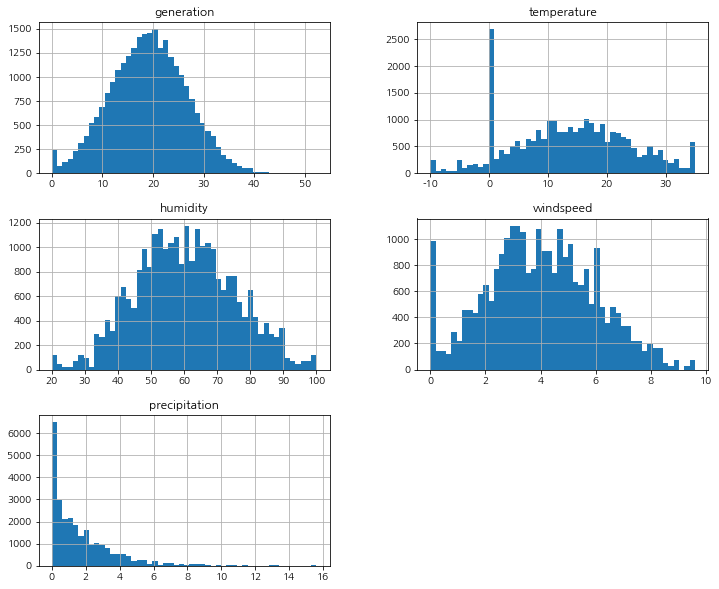

범주형 변수 통계량 및 시각화


,count,unique,top,freq
time,26280,24,6,1095
season,26280,4,여름,6624


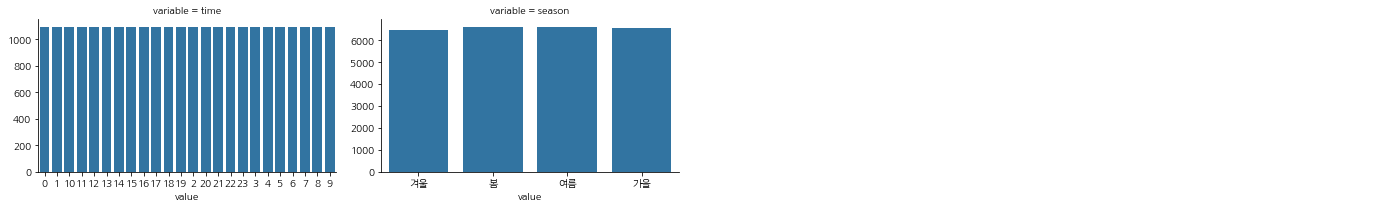

In [59]:
c_cols = mg.select_dtypes('O').columns
n_cols = mg.select_dtypes('number').columns

print(f"수치형 변수 통계량 및 시각화")
display(mg[n_cols].describe().T)
mg[n_cols].hist(bins=50, layout=(3, 2), figsize=(12, 10))
plt.show()

print(f"범주형 변수 통계량 및 시각화")
display(mg[c_cols].describe().T)
mt = mg[c_cols].melt()
g = sns.FacetGrid(mt, col='variable', col_wrap=4, aspect=1.6, sharex=False, sharey=False)
g.map(sns.countplot, 'value')
g.add_legend()
plt.show()

기본적인 통계량 및 분포 시각화로 확인한다.  
발전량, 습도, 풍속은 정규분포에 가까운 형태를 보인다.  
temperture는 다소 첨도가 낮다.  

precipitation는 오른쪽 긴꼬리인 양의 왜도를 가진다.(성능향상을 위해 로그화 고려할 수 있음)  

시간은 균등하며, 계절 분포도 균등하다. 

종속변수와 연속형 변수는 피어슨 상관관계 분석을 통해 절대값 0.7 이상의 변수를 확인한다.   
종속변수와 명목형 변수는 정규성을 만족한다면 one-way anova, 만족하지 않는다면 크루스칼 왈리스 검정 수행

In [61]:
from scipy.stats import pearsonr

# 먼저 연속형 변수
for c in n_cols[1:]:
    e, p = pearsonr(mg['generation'], mg[c])
    print(f"{c} 변수 피어슨 상관관계: {e:.3f} / pvalue: {p:.2f}")

temperature 변수 피어슨 상관관계: 0.010 / pvalue: 0.12
humidity 변수 피어슨 상관관계: 0.001 / pvalue: 0.85
windspeed 변수 피어슨 상관관계: 0.018 / pvalue: 0.00
precipitation 변수 피어슨 상관관계: -0.018 / pvalue: 0.00


종속변수와 유의미한 양/음의 상관관계가 식별되지 않았다.   
또한 temperature , humidity 변수는 통계적으로 유의하지 않아 피어슨 상관계수를 신뢰할 수 없다. 

In [62]:
vif = pd.DataFrame()

vif['name'] = n_cols
vif['vif'] = [variance_inflation_factor(mg[n_cols].values, i) for i in range(len(n_cols))]

display(vif)

,name,vif
0,generation,6.048928
1,temperature,2.696520
2,humidity,7.936348
3,windspeed,4.328360
4,precipitation,1.779574


다중공선성은 식별되지 않는다. 

In [162]:
g = [(name, g['generation']) for name, g in mg.groupby('season')]

for n, g in g:
    s, p = shapiro(g)
    print(f"{n} 정규성 검정통계량/pvalue: {s} / {p:.2f}")

가을 정규성 검정통계량/pvalue: 0.9984261393547058 / 0.00
겨울 정규성 검정통계량/pvalue: 0.9987938404083252 / 0.00
봄 정규성 검정통계량/pvalue: 0.9986898303031921 / 0.00
여름 정규성 검정통계량/pvalue: 0.9979246854782104 / 0.00


In [172]:
g = [g['generation'] for name, g in mg.groupby('season')]

pg.anova(dv='generation', between='season', detailed=True, data=mg)

,Source,SS,DF,MS,F,p-unc,np2
0,season,7.669964e+02,3,255.665483,4.601458,0.003189,0.000525
1,Within,1.459943e+06,26276,55.561842,NaN,NaN,NaN


In [174]:
df = pd.DataFrame({
    'Subject': list(range(1,11))*3,
    'Method': ['A']*10 + ['B']*10 + ['C']*10,
    'Score': [78,72,85,90,65,80,70,88,75,82,
              82,75,88,92,68,83,74,90,78,85,
              85,74,90,95,70,85,78,92,80,88]
})

# Friedman 검정
res = pg.friedman(data=df, dv='Score', within='Method', subject='Subject', )
display(res)

,Source,ddof1,Q,p-unc
Friedman,Method,2,18.2,0.000112


In [177]:
len(df)

30

In [176]:
18.2/(len(df)*2)

0.30333333333333334

정규성을 만족하지 않으므로 크루스칼 왈리스 검정 수행  

- 귀무가설: 계절에 따라 종속변수 차이가 없다.
- 대립가설: 계절에 따라 종속변수 차이가 있다.

In [161]:
from scipy.stats import kruskal
from scipy.stats.contingency import association


cr = pd.crosstab(mg['generation'], mg['season'])

rs = pg.kruskal(data=mg, dv='generation', between='season', detailed=True)

display(rs)

,Source,ddof1,H,p-unc
Kruskal,season,3,10.793427,0.012897


0.05보다 작으므로 통계적으로 유의, 
(종속변수 예측 특징이 강함)

#### 5. 데이터 분할 및 예측:
- 2021~2022년 데이터를 학습(train), 2023년 데이터를 테스트(test)로 분할.
- 선형회귀, 랜덤포레스트를 사용하여 총 발전량(generation) 예측.
- 성능 평가: RMSE, R².

In [72]:
train, test = mg[mg['date'].dt.year.isin(['2021', '2022'])], mg[mg['date'].dt.year.isin(['2023'])]

train.shape, test.shape

((17520, 8), (8760, 8))

In [76]:
train_x, train_y = train.drop(columns=['generation', 'date']), train['generation']
test_x, test_y = test.drop(columns=['generation', 'date']), test['generation']

c_cols = train_x.select_dtypes('O').columns
n_cols = train_x.select_dtypes('number').columns

train_x = pd.get_dummies(train_x, columns=c_cols, drop_first=True)
test_x = pd.get_dummies(test_x, columns=c_cols, drop_first=True)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression


lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)

m_list = [('선형회귀',  lr), ('랜덤포레스트회귀', rf)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'r2', 'rmse'])

for n1, model in m_list:
    model.fit(train_x, train_y)
    for n2, x, y, in d_list:
        pred = model.predict(x)
        r2 = r2_score(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        rs.loc[len(rs)] = [n1, n2, r2, rmse]
display(rs)

,model,data,r2,rmse
0,선형회귀,train,0.004771,7.497419
1,선형회귀,test,-0.008584,7.363429
2,랜덤포레스트회귀,train,0.869673,2.713113
3,랜덤포레스트회귀,test,-0.076384,7.606898


In [77]:
7.363429/(test_y.max()- test_y.min())

0.1562313815091767

두 모델 학습 결과이다.  랜덤포레스트 회귀는 과적합이 발생하여 실무에 활용하기 적합하지 않다.  

선형회귀 모델은 일반화 성능을 보여주고 있으며, 랜덤포레스트 회귀보다 다소 성능이 높다.  

선형회귀 테스트 셋 기준으로 평가하면 r2 설명력이 음수를 보이고 있어, 일반적으로 평균을 예측하는 모델보다 성능이 떨어진다고 할 수   
있으며, rmse는 7.363429으로 test set 범위 대비 약 15.6%의 표준오차를 보이고 있다.  
따라서 성능이 좋은 모델은 아니지만, 실험/관찰 단계에서 사용하기는 적합할 것이다.  
다만 위에서 설명변수-종속변수 간 통계적으로 유의한 변수가 없었으로 종속변수를 잘 예측할 수 있는 특징을 가진 파생변수를 생성하던지  
추가적인 데이터를 수집하는 등의 성능향상을 고려할 수 있을 것이다.

### 3. 통계분석

#### [문제 3] 분산분석: 학습방법과 성별에 따른 성적 분석
#### 데이터셋은 학생 40명(남 20, 여 20)의 학습방법(3가지)별 성적을 포함합니다.
##### 변수:
- ID: 학생 식별자
- Gender: 성별 (M/F)
- LearningMethod: 학습방법 (Traditional, Online, Blended)
- Score: 성적 (0~100점)
##### 데이터 특이사항:
- 성적 분포: 평균 75, 표준편차 10 내외.
- Python(statsmodels) 또는 R(aov, TukeyHSD) 사용 권장.

In [3]:
d3 = pd.read_csv('./Learning_Score.csv')

In [4]:
d3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           40 non-null     int64 
 1   Gender       40 non-null     object
 2   Traditional  40 non-null     int64 
 3   Online       40 non-null     int64 
 4   Blended      40 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.7+ KB


In [5]:
d3.head()

,id,Gender,Traditional,Online,Blended
0,1,M,89,65,58
1,2,M,73,82,76
2,3,M,80,82,74
3,4,M,83,50,93
4,5,M,78,56,86


#### 1. 가정 검토:

해당 문제는 종속변수가 연속형 변수이며, 설명변수가 명목형 변수이다.  

설명변수는 성별과 학습방식인데, 이 중 성별은 독립요인이며(between), 학습방식은 조건에 따라 동시에 발생하는 반복측정 요인(within)   
이므로 혼합설계 anova를 수행한다.  

다음의 가정이 검토되어야 한다.  
- 정규성: 각 그룹(6개) 내 잔차는 정규분포를 따름
- 독립성: between 관찰값은 서로 독립적(수집단계에서 만족하는 것으로 가정)
- 구형성: 반복측정 요인 수준간 차이의 분산(공분산 행렬)이 동일
- 등분산성: between 그룹간 분산이 동일  

유의수준 5% 하에서 검정을 수행하며, 정규성의 경우 선형회귀 학습 후 잔차를 이용하지만 모델 사용전 탐색적 목적으로 그룹별 종속변수  
데이터로 수행한다.

In [6]:
mt = d3.melt(id_vars=['id', 'Gender'], var_name='method', value_name='score')

In [7]:
from scipy.stats import shapiro, levene, probplot

# 정규성 검정
gr = [(name, g['score']) for name, g in mt.groupby(['Gender', 'method'])]

for n, g in gr:
    s, p = shapiro(g)
    print(f"{n} 그룹 정규성 검정통계량/pvalue: {s} / {p:.3f}")

('F', 'Blended') 그룹 정규성 검정통계량/pvalue: 0.9480578899383545 / 0.339
('F', 'Online') 그룹 정규성 검정통계량/pvalue: 0.9189079403877258 / 0.094
('F', 'Traditional') 그룹 정규성 검정통계량/pvalue: 0.9564768075942993 / 0.476
('M', 'Blended') 그룹 정규성 검정통계량/pvalue: 0.9610829949378967 / 0.566
('M', 'Online') 그룹 정규성 검정통계량/pvalue: 0.9232606887817383 / 0.115
('M', 'Traditional') 그룹 정규성 검정통계량/pvalue: 0.9768011569976807 / 0.886


유의수준 5% 하에서 모든 그룹에서 정규성을 만족한다.(귀무가설 만족)

In [8]:
gr = [g['score'] for name, g in mt.groupby(['Gender'])]

s, p = levene(*gr)

print(f"독립요인 등분산성 검정통계량/pvalue: {s} / {p}")

독립요인 등분산성 검정통계량/pvalue: 0.2228453349376157 / 0.6377522248545682


유의수준 5% 하에서 독립요인 등분산성 만족(귀무가설 기각)  구형성은 모델 적합 후 Greenhouse Geiser 확인  
계수가 1에 가까우면(일반적으로 0.75이상) 구형성을 만족하는 것으로 함

In [9]:
import pingouin as pg

mix = pg.mixed_anova(dv='score', within='method', between='Gender', subject='id', data=mt)

display(mix)

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Gender,0.033333,1,38,0.033333,0.000260,9.872168e-01,0.000007,NaN
1,method,4539.216667,2,76,2269.608333,22.577354,2.013656e-08,0.372703,0.995929
2,Interaction,118.816667,2,76,59.408333,0.590976,5.563113e-01,0.015314,NaN


유의수준 5% 하 혼합설계 모형 적합결과, 반복측정 요인인 방식의 gg-eps가 0.995929로 구형성 또한 만족한다.

#### 2. 분산분석:


위에서 기본가정 확인 간 혼합설계 모형을 적합하였을 시 유의수준 5% 하 교호작용과 독립요인의 pvalue가 0.05보다 커서  
통계적으로 유의하지 못했다. 따라서 독립요인은 배제하고 반복측정 요인인 method만을 활용하여 일원 반복측정 분산분석을 수행한다.  

다음과 같이 유의수준 5% 하 가설을 수립 후 검정한다.   
- 귀무가설: 학습방식에 따른 국어성적 평균 차이는 없다.  
- 대립가설: 적어도 하나의 학습방식에 따라 국어성적 평균 차이가 있다. 

In [10]:
rp = pg.rm_anova(dv='score', within='method', subject='id', data=mt, detailed=True, correction=True)

display(rp)

,Source,SS,DF,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,method,4539.216667,2,2269.608333,22.816651,1.579088e-08,1.676235e-08,0.369102,0.995929,True,0.995913,0.925132
1,Error,7758.783333,78,99.471581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


다음과 같이 유의수준 5% 하 검정결과 역시 구형성을 만족하며(0.995929), pvlaue 1.579088e-08로 귀무가설을 기각한다.  
따라서 적어도 하나의 학습방식에 따라 국어성적 평균 차이가 있다는 대립가설은 통계적으로 유의하다.

#### 3. 사후분석:
- 유의미한 효과가 발견될 경우, Tukey HSD 테스트로 사후분석 수행.

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
Blended      Online  -14.525    0.0 -20.0399 -9.0101   True
Blended Traditional     -3.8 0.2348  -9.3149  1.7149  False
 Online Traditional   10.725    0.0   5.2101 16.2399   True
-----------------------------------------------------------


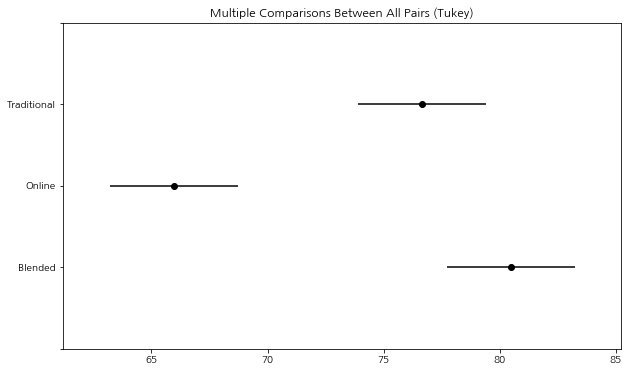

In [11]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rs = pairwise_tukeyhsd(endog=mt['score'], groups=mt['method'], alpha=0.05)

print(rs)

rs.plot_simultaneous()
plt.show()

#### 4. 결과 해석:
- 각 효과의 p-value와 통계적 유의성 논의.
- 학습방법별 평균 성적 비교 시각화.

tukey hsd 검정결과, 

- Blended - Online: 평균의 차이가 통계적으로 유의(0.0)
- Blended - Traditional: 평균의 차이가 유의하지 않음(0.2348)
- Online - Traditional: 평균의 차이가 유의(0.0)  

그룹별 평균값을 보면 통계적으로 유의하지는 않지만  Blended가 Traditional보다 높다. 따라서 비용, 시각적인 측면 등을 고려하여  
두 학습방식 중 선택하는 것을 고려할 수 있다. 
    

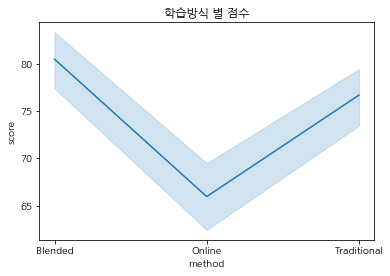

In [13]:
sns.lineplot(data=mt, x='method', y='score')
plt.title('학습방식 별 점수')
plt.show()

### 4. 통계분석

#### [문제 4] 회귀분석: 학업 성취도 예측

#### 데이터셋은 학생 500명의 학업 관련 변수를 포함하며, 국어 성적을 예측하는 회귀분석을 수행합니다.

- 변수:
- ID: 학생 식별자
- StudyTime: 주간 공부시간 (0: 10시간 이하, 1: 1115시간, 2: 1620시간, 3: 21~25시간, 4: 26시간 이상)
- Tutoring: 과외 여부 (Yes/No)
- OnlineCourse: 온라인 강의 수강 여부 (Yes/No)
- Absences: 결석 일수 (평균 4, Q3: 8, 최대 25)
- Failures: 낙제 횟수 (0~3)
- Score: 국어 성적 (0~20점)
#### 데이터 특이사항:
- 결측값: 약 5% (Absences, Failures 중심).
- 범주형 변수(Tutoring, OnlineCourse)는 더미 변수로 변환 필요.
- Python(sklearn, statsmodels) 또는 R(lm, randomForest) 사용 권장.

In [147]:
d4 = pd.read_csv('Academic_Performance.csv')

In [148]:
d4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            500 non-null    int64  
 1   StudyTime     500 non-null    int64  
 2   Tutoring      500 non-null    object 
 3   OnlineCourse  500 non-null    object 
 4   Absences      475 non-null    float64
 5   Failures      475 non-null    float64
 6   Score         500 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 27.5+ KB


In [149]:
d4.isna().mean()

id              0.00
StudyTime       0.00
Tutoring        0.00
OnlineCourse    0.00
Absences        0.05
Failures        0.05
Score           0.00
dtype: float64

수집된 데이터이며, 선형회귀 모델은 이상치, 결측치에 민감하므로 데이터의 왜곡을 피하기 위해 결측 데이터를 삭제한다. 

In [150]:
print(f"결측치 삭제 전: {len(d4)}")
d4 = d4.dropna()
print(f"결측치 삭제 후: {len(d4)}")

결측치 삭제 전: 500
결측치 삭제 후: 475


In [151]:
d4.head()

,id,StudyTime,Tutoring,OnlineCourse,Absences,Failures,Score
0,1,3,Yes,Yes,8.0,0.0,12
1,2,1,Yes,Yes,4.0,2.0,11
2,3,1,Yes,No,7.0,1.0,14
3,4,2,No,No,7.0,1.0,14
4,5,0,No,Yes,5.0,1.0,11


#### 가정 검토:
선형회귀 가정(선형성, 정규성, 등분산, 독립성) 검토.
잔차 플롯 및 Q-Q 플롯 시각화



다중선형회귀는 회귀계수 및 모델학습결과를 신뢰하기 위해서 잔차의 가정을 만족해야만 한다.  
해당 가정이 유의하지 않다면 회귀계수의 왜곡이 발생하기 때문이다.  

- 선형성: 독립변수와 종속변수 간 선형관계
- 독립성: 잔차들이 서로 독립
- 등분산성: 모든 x 값에서 잔차 분산 동일
- 정규성: 잔차가 정규분포를 따름
- 다중공선성 없음: 독립변수 간 높은 상관관계가 없어야 함


In [152]:
d4['StudyTime'] = d4['StudyTime'].astype('O')

In [153]:
x

,birth_weight,gestational_age,maternal_age,hospital_days,apgar_score,oxygen_days,body_temp,twins,c_section,rds,d,e,f,infection,ventilation,gender
868,1631.708855,29.818067,32.674087,6,9,3,36.920051,No,Yes,No,Severe,None,None,Yes,No,F
93,1434.467571,32.103892,24.305834,8,9,1,36.824874,No,Yes,No,Mild,None,None,No,No,M
144,1551.976559,31.653856,28.883989,7,4,0,36.590791,No,No,No,Severe,Mild,None,Yes,No,M
172,1484.579658,32.208402,28.400762,12,6,1,37.132032,No,Yes,No,None,None,None,No,Yes,F
932,1210.397220,31.069379,25.553796,7,4,2,36.813366,Yes,Yes,Yes,None,None,None,Yes,No,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,1278.733005,34.297531,31.952324,5,6,1,37.295874,No,Yes,No,None,None,None,No,No,F
674,1218.497661,35.230751,24.957227,9,4,4,36.662290,No,No,Yes,Mild,Severe,None,No,No,M
152,1363.995056,30.722077,30.104432,6,7,3,36.932106,No,Yes,No,None,None,None,No,No,F
991,1091.653026,33.508583,33.010592,12,8,1,36.709961,No,No,No,None,Mild,None,No,No,F


In [154]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

x = d4.drop(columns=['id', 'Score'])
y = d4['Score']

c_cols = x.select_dtypes('O').columns

x = pd.get_dummies(x, columns=c_cols, drop_first=True)

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42)

print(train_x.shape, test_x.shape)


lr = sm.OLS(train_y, sm.add_constant(train_x)).fit()

(356, 8) (119, 8)


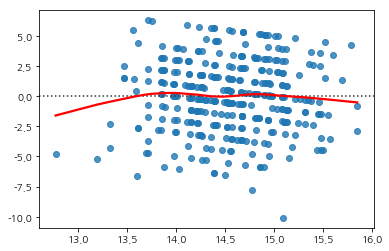

정규성 검정 통계량/pvalue: 0.9923514127731323 / 0.06479701399803162
등분산성 검정 통계량/pvalue: 7.913361857858231 / 0.44197871889116336
독립성 검정결과: 1.901287301373148


In [155]:
# 선형회귀 기본가정 확인
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

fitted = lr.fittedvalues
resid = lr.resid

#정규성 검정
sns.residplot(fitted, resid, lowess=True, line_kws={'color': 'r'})
plt.show()

s, p = shapiro(resid)
print(f"정규성 검정 통계량/pvalue: {s} / {p}")

#등분산성 검정
s, p, _, _ = het_breuschpagan(resid, lr.model.exog)

print(f"등분산성 검정 통계량/pvalue: {s} / {p}")

#독립성 검정
dw = durbin_watson(resid)
print(f"독립성 검정결과: {dw}")

In [156]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = lr.model.exog_names
vif['vif'] = [variance_inflation_factor(lr.model.exog, i) for i in range(len(lr.model.exog_names))]

display(vif[1:])

,name,vif
1,Absences,1.036553
2,Failures,1.019823
3,StudyTime_1,1.653966
4,StudyTime_2,1.717767
5,StudyTime_3,1.397598
6,StudyTime_4,1.303099
7,Tutoring_Yes,1.021990
8,OnlineCourse_Yes,1.024629


- 선형성: 만족(잔차 패턴 보이지 않으며, 0 기준으로 고르게 분포)
- 정규성: 만족(귀무가설을 기각할 수 없음)
- 등분산성:만족(귀무가설 기각 불가)
- 독립성: 만족(더빈왓슨 검정결과 1.5-2.5 사이)
- 다중공선성: 없음(vif 가 1에 가까움)

#### 회귀분석:
선형회귀분석 수행(종속변수: Score, 독립변수: StudyTime, Tutoring, OnlineCourse, Absences, Failures).
기계학습 모델(예: 랜덤포레스트)과 비교.

In [157]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(random_state=42)

rf.fit(train_x, train_y)

m_list = [('다중선형회귀', lr), ('랜덤포레스트회귀', rf)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'r2', 'rmse'])

for n1, model in m_list:
    for n2, x, y in d_list:
        if n1 =='다중선형회귀':
            pred = model.predict(sm.add_constant(x))
        else:
            pred = model.predict(x)
        r2 = r2_score(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        rs.loc[len(rs)] = [n1, n2, r2, rmse]
display(rs)

,model,data,r2,rmse
0,다중선형회귀,train,0.029284,2.966007
1,다중선형회귀,test,-0.036000,2.701539
2,랜덤포레스트회귀,train,0.549281,2.021060
3,랜덤포레스트회귀,test,-0.474444,3.222889


두 모델 학습 후 종속변수 변동을 설명하는 r2_socre와 오차제곱합인 rmse로 평가하였다.  

두 모델 모두에서 과적합은 없었으며, 다중선형회귀의 성능이 확연히 좋은 것을 확인할 수 있다.  
다만 다중선형회귀의 r2 score가 음수로 종속변수의 분산변동을 설명하지 못하는데(단순 평균예측모델보다 성능 떨어짐)  이는 아래의  
모델 학습결과에서 F 통계량의 pvalue가 0.238로 통계적으로 유의하지 못하여 설명변수의 회귀계수가 왜곡되었기 때문이라고  
판단할 수 있다. 

In [31]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.309
Date:                Fri, 17 Oct 2025   Prob (F-statistic):              0.238
Time:                        10:02:17   Log-Likelihood:                -892.19
No. Observations:                 356   AIC:                             1802.
Df Residuals:                     347   BIC:                             1837.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               14.6883      0.524  

먼저 다중선형회귀는 F 통계량의 pvalue가 유의수준 5% 하에서 유의하지 않았으며(0.238)  
이는 통계적으로 유의한 모델이 아니라는 것을 의미한다.(회귀계수가 0이 아니라는 통계적 유의성 없음)  

각 독립변수의 t 통계량 pvalue를 확인해 보아도 유의한 변수가 하나도 없었다.  
따라서 나쁜 성능을 내는 것으로 결론낼 수 있다. 

#### 다중공선성:
VIF(Variance Inflation Factor) 계산 및 다중공선성 평가.

In [32]:
display(vif)

,name,vif
0,const,10.817497
1,Absences,1.036553
2,Failures,1.019823
3,StudyTime_1,1.653966
4,StudyTime_2,1.717767
5,StudyTime_3,1.397598
6,StudyTime_4,1.303099
7,Tutoring_Yes,1.021990
8,OnlineCourse_Yes,1.024629


#### 변수 중요도:
회귀계수의 p-value를 통해 통계적 유의성 확인.
랜덤포레스트의 feature importance 분석.

통계적으로 유의한 변수가 하나도 없다. 

랜덤 포레스트 회귀학습 후 featuer importance이다.   
모든 변수가 모델학습에 10% 이상 영향을 주었다. 
결석여부가 가장 모델학습에 영향을 주었고, 그 다음 학습시간, 낙제여부 순으로 중요한 영향을 미쳤다. 

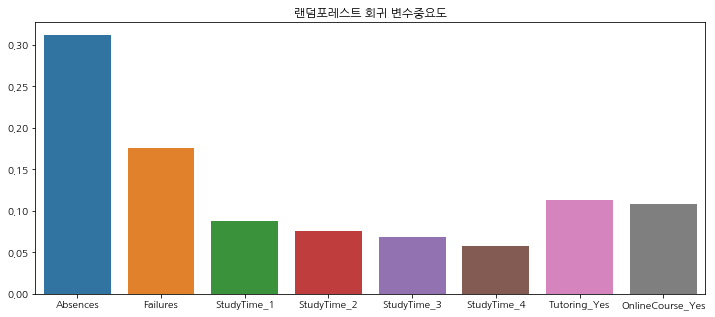

In [35]:
imp = rf.feature_importances_
name = train_x.columns

plt.figure(figsize=(12, 5))

sns.barplot(y=imp, x=name)
plt.title('랜덤포레스트 회귀 변수중요도')
plt.show()

다음과 같이 랜덤포레스트 학습 성능에 영향을 미치는 변수를 확인할 수 있다.  
결석, 낙제가 높은 영향을 주었으며, 학습시간은 비교적 낮은 영향을 준다고 할 수 있다.

#### 모델 평가:
R²: 모델이 성적의 변동을 얼마나 설명하는지 해석.
RMSE: 예측 오차 평가.

In [36]:
3.222889/(test_y.max() - test_y.min())

0.2685740833333333

랜덤 포레스트 회귀 모형 기준으로 학습결과를 확인하면, r2 스코어가 음수값이다. 이는 기본적으로 평균을 예측하는 모델보다 예측성능이  
떨어진다는 것을 의미하며, rmse는 test_set 데이터 범위 간 약 26.9%의 표준오차를 가진다고 할 수 있다.  
비교적 나쁜 성능의 모델이라고 할 수 있다. 